## Data Preparation

### Load the Dataset

In [1]:
import kagglehub

path = kagglehub.dataset_download("pkdarabi/helmet")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'helmet' dataset.
Path to dataset files: /kaggle/input/helmet


### Perform train/val/test split (70/20/10)



In [3]:
import os

all_image_paths = {}
all_label_paths = {}

version_identifiers = ['HelmetViolationsV2', 'HelmetViolations']
version_folders_list = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f)) and f in version_identifiers]

for version in version_folders_list:
    version_path = os.path.join(path, version)
    all_image_paths[version] = {}
    all_label_paths[version] = {}

    split_folders_list = [f for f in os.listdir(version_path) if os.path.isdir(os.path.join(version_path, f)) and f in ['train', 'valid', 'test']]

    for split in split_folders_list:
        split_path = os.path.join(version_path, split)
        all_image_paths[version][split] = []
        all_label_paths[version][split] = []

        # Collecting image paths
        images_dir = os.path.join(split_path, 'images')
        if os.path.isdir(images_dir):
            for img_file in os.listdir(images_dir):
                all_image_paths[version][split].append(os.path.join(images_dir, img_file))

        # Collecting label paths
        labels_dir = os.path.join(split_path, 'labels')
        if os.path.isdir(labels_dir):
            for label_file in os.listdir(labels_dir):
                all_label_paths[version][split].append(os.path.join(labels_dir, label_file))

# Printing counts for verification
print("Collected File Paths Summary:")
for version, splits in all_image_paths.items():
    print(f"\nVersion: {version}")
    for split, paths in splits.items():
        print(f"  Split: {split}")
        print(f"    Images: {len(paths)}")
        if split in all_label_paths[version]:
            print(f"    Labels: {len(all_label_paths[version][split])}")
        else:
            print(f"    Labels: 0 (No labels found for this split)")

Collected File Paths Summary:

Version: HelmetViolationsV2
  Split: valid
    Images: 30
    Labels: 30
  Split: test
    Images: 11
    Labels: 11
  Split: train
    Images: 963
    Labels: 963

Version: HelmetViolations
  Split: valid
    Images: 30
    Labels: 30
  Split: test
    Images: 7
    Labels: 7
  Split: train
    Images: 896
    Labels: 896


In [ ]:
import os
import shutil
import random
from glob import glob

# Base directory where the dataset is located after downloading
dataset_path = '/kaggle/input/helmet'
base_data_dir = os.path.join(dataset_path, 'HelmetViolationsV2')

# Define target directories for the new split
output_base_dir = './custom_split_70_20_10'

# Create output directories if they don't exist
train_images_dir = os.path.join(output_base_dir, 'train', 'images')
train_labels_dir = os.path.join(output_base_dir, 'train', 'labels')
val_images_dir = os.path.join(output_base_dir, 'val', 'images')
val_labels_dir = os.path.join(output_base_dir, 'val', 'labels')
test_images_dir = os.path.join(output_base_dir, 'test', 'images')
test_labels_dir = os.path.join(output_base_dir, 'test', 'labels')

for d in [train_images_dir, train_labels_dir, val_images_dir, val_labels_dir, test_images_dir, test_labels_dir]:
    os.makedirs(d, exist_ok=True)

print(f"Created output directories for custom split at: {output_base_dir}")

# Gather all image paths from the existing train, valid, and test sets
all_image_paths = []
for split_type in ['train', 'valid', 'test']:
    images_dir = os.path.join(base_data_dir, split_type, 'images')
    # Assuming all images are .jpg, adjust if other formats exist
    all_image_paths.extend(glob(os.path.join(images_dir, '*.jpg')))

print(f"Found {len(all_image_paths)} total images across all original splits.")

# Shuffle the image paths for a random split
random.seed(42) # for reproducibility
random.shuffle(all_image_paths)

# Define split ratios
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

total_images = len(all_image_paths)
train_count = int(total_images * train_ratio)
val_count = int(total_images * val_ratio)
test_count = total_images - train_count - val_count # Ensure all images are accounted for

train_files = all_image_paths[:train_count]
val_files = all_image_paths[train_count : train_count + val_count]
test_files = all_image_paths[train_count + val_count :]

print(f"New split counts: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

# Function to copy images and their corresponding label files
def copy_files(file_list, dest_image_dir, dest_label_dir, source_base_data_dir):
    for img_path in file_list:
        img_filename = os.path.basename(img_path)
        img_name_no_ext = os.path.splitext(img_filename)[0]

        # Determine the relative path to find the corresponding label file
        relative_img_path = os.path.relpath(img_path, source_base_data_dir)
        label_relative_path = relative_img_path.replace('images', 'labels').replace(os.path.splitext(img_filename)[1], '.txt')
        original_label_path = os.path.join(source_base_data_dir, label_relative_path)

        # Copy image
        shutil.copy(img_path, os.path.join(dest_image_dir, img_filename))

        # Copy label if it exists (assuming YOLO format .txt labels)
        if os.path.exists(original_label_path):
            shutil.copy(original_label_path, os.path.join(dest_label_dir, img_name_no_ext + '.txt'))
        else:
            print(f"Warning: Label file not found for {img_path} at {original_label_path}")

print("Copying train files...")
copy_files(train_files, train_images_dir, train_labels_dir, base_data_dir)
print("Copying validation files...")
copy_files(val_files, val_images_dir, val_labels_dir, base_data_dir)
print("Copying test files...")
copy_files(test_files, test_images_dir, test_labels_dir, base_data_dir)

print("Dataset split and copied successfully.")

# Print final counts for verification
print("\n--- Final Split Counts ---")
print(f"Train images: {len(glob(os.path.join(train_images_dir, '*')))}")
print(f"Train labels: {len(glob(os.path.join(train_labels_dir, '*')))}")
print(f"Validation images: {len(glob(os.path.join(val_images_dir, '*')))}")
print(f"Validation labels: {len(glob(os.path.join(val_labels_dir, '*')))}")
print(f"Test images: {len(glob(os.path.join(test_images_dir, '*')))}")
print(f"Test labels: {len(glob(os.path.join(test_labels_dir, '*')))}")

Created output directories for custom split at: ./custom_split_70_20_10
Found 1004 total images across all original splits.
New split counts: Train=702, Val=200, Test=102
Copying train files...
Copying validation files...
Copying test files...
Dataset split and copied successfully.

--- Final Split Counts ---
Train images: 702
Train labels: 697
Validation images: 200
Validation labels: 199
Test images: 102
Test labels: 102


In [4]:
all_class_ids = []
all_bbox_widths = []
all_bbox_heights = []

for version in all_label_paths:
    for split in all_label_paths[version]:
        for label_path in all_label_paths[version][split]:
            try:
                with open(label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) == 5:
                            class_id = int(parts[0])
                            width = float(parts[3])
                            height = float(parts[4])

                            all_class_ids.append(class_id)
                            all_bbox_widths.append(width)
                            all_bbox_heights.append(height)
            except FileNotFoundError:
                print(f"Warning: Label file not found at {label_path}")
            except Exception as e:
                print(f"Error processing {label_path}: {e}")

print(f"Total class IDs collected: {len(all_class_ids)}")
print(f"Total bounding box widths collected: {len(all_bbox_widths)}")
print(f"Total bounding box heights collected: {len(all_bbox_heights)}")

Total class IDs collected: 2671
Total bounding box widths collected: 2671
Total bounding box heights collected: 2671


### Apply augmentation:

- Horizontal flip

- Brightness change

- Scaling

- Random crop



Applying augmentation to sample image: ./custom_split_70_20_10/train/images/685_jpg.rf.d9755e0139ad52fff04e2ab1f573cbba.jpg


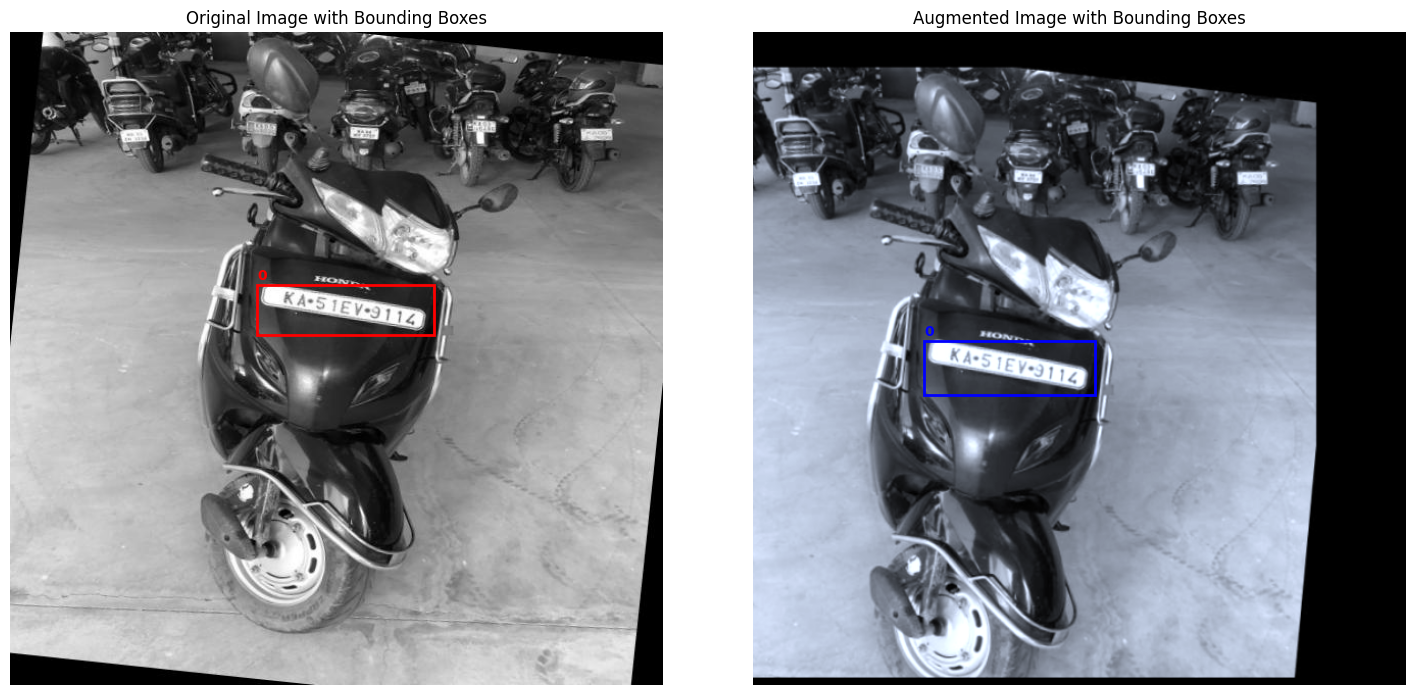

Demonstration augmented image and labels saved to ./augmented_data_demo/images and ./augmented_data_demo/labels
Augmentation pipeline defined and demonstration complete.


In [ ]:
import imgaug as ia
import imgaug.augmenters as iaa
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import random
from glob import glob

ia.seed(42)

seq = iaa.Sequential([
    iaa.Fliplr(0.5), # horizontal flips
    iaa.Sometimes(0.5, iaa.Multiply((0.7, 1.3), per_channel=0.5)), # change brightness
    iaa.Affine(scale={"x": (0.8, 1.2), "y": (0.8, 1.2)}), # scale images
    iaa.Sometimes(0.5, iaa.CropAndPad(percent=(-0.25, 0.25))) # random crop/pad
], random_order=True) # apply augmenters in random order

# --- Helper functions for YOLO format conversion ---

def load_yolo_annotations(label_path, img_width, img_height):
    """Loads YOLO format annotations from a file and converts them to imgaug BoundingBoxesOnImage."""
    bboxes = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])

                # Convert normalized (center_x, center_y, width, height) to absolute (x1, y1, x2, y2)
                x1 = int((x_center - width / 2) * img_width)
                y1 = int((y_center - height / 2) * img_height)
                x2 = int((x_center + width / 2) * img_width)
                y2 = int((y_center + height / 2) * img_height)
                bboxes.append(ia.BoundingBox(x1=x1, y1=y1, x2=x2, y2=y2, label=class_id))
    return ia.BoundingBoxesOnImage(bboxes, shape=(img_height, img_width, 3))

def save_yolo_annotations(output_label_path, bboxes_aug, img_width, img_height):
    """Saves imgaug BoundingBoxesOnImage to YOLO format."""
    with open(output_label_path, 'w') as f:
        for bbox in bboxes_aug.bounding_boxes:
            # Ensure bounding box coordinates are within image boundaries after augmentation
            x1 = max(0, bbox.x1_int)
            y1 = max(0, bbox.y1_int)
            x2 = min(img_width, bbox.x2_int)
            y2 = min(img_height, bbox.y2_int)

            if x2 <= x1 or y2 <= y1: # Skip invalid bounding boxes (e.g., if cropped out completely)
                continue

            # Convert absolute (x1, y1, x2, y2) to normalized (center_x, center_y, width, height)
            x_center = ((x1 + x2) / 2) / img_width
            y_center = ((y1 + y2) / 2) / img_height
            width = (x2 - x1) / img_width
            height = (y2 - y1) / img_height
            f.write(f"{bbox.label} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

def augment_and_save(image_path, label_path, output_image_dir, output_label_dir, augmenter, num_augmentations=1):
    """Applies augmentation to an image and its labels and saves them."""
    img = cv2.imread(image_path)
    if img is None:
        print(f"Warning: Could not read image {image_path}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_height, img_width, _ = img.shape

    bboxes = load_yolo_annotations(label_path, img_width, img_height)

    base_name = os.path.splitext(os.path.basename(image_path))[0]

    for i in range(num_augmentations):
        # Augment image and bounding boxes
        image_aug, bboxes_aug = augmenter(image=img, bounding_boxes=bboxes)

        # Define output paths
        output_img_path = os.path.join(output_image_dir, f"{base_name}_aug_{i}.jpg")
        output_label_path = os.path.join(output_label_dir, f"{base_name}_aug_{i}.txt")

        # Save augmented image and labels
        cv2.imwrite(output_img_path, cv2.cvtColor(image_aug, cv2.COLOR_RGB2BGR))
        save_yolo_annotations(output_label_path, bboxes_aug, image_aug.shape[1], image_aug.shape[0])

# --- Demonstration ---

# Use the directories created in the previous step
TRAIN_IMAGES_DIR = './custom_split_70_20_10/train/images'
TRAIN_LABELS_DIR = './custom_split_70_20_10/train/labels'

# Create a directory for augmented data demonstration
DEMO_AUG_IMAGES_DIR = './augmented_data_demo/images'
DEMO_AUG_LABELS_DIR = './augmented_data_demo/labels'
os.makedirs(DEMO_AUG_IMAGES_DIR, exist_ok=True)
os.makedirs(DEMO_AUG_LABELS_DIR, exist_ok=True)

# Get a list of all training images
train_image_paths = glob(os.path.join(TRAIN_IMAGES_DIR, '*.jpg'))

if train_image_paths:
    # Select a random image for demonstration
    sample_image_path = random.choice(train_image_paths)
    sample_label_path = os.path.join(TRAIN_LABELS_DIR, os.path.basename(sample_image_path).replace('.jpg', '.txt'))

    print(f"Applying augmentation to sample image: {sample_image_path}")

    # Load original image and its annotations
    original_img = cv2.imread(sample_image_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    original_h, original_w, _ = original_img.shape
    original_bboxes = load_yolo_annotations(sample_label_path, original_w, original_h)

    # Apply augmentation and get the augmented image and bounding boxes
    augmented_img, augmented_bboxes = seq(image=original_img, bounding_boxes=original_bboxes)

    # Plot original vs. augmented image with bounding boxes
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # Original Image
    axes[0].imshow(original_img)
    for bbox in original_bboxes.bounding_boxes:
        rect = plt.Rectangle((bbox.x1, bbox.y1), bbox.width, bbox.height, fill=False, edgecolor='red', linewidth=2)
        axes[0].add_patch(rect)
        axes[0].text(bbox.x1, bbox.y1 - 5, str(bbox.label), color='red', fontsize=10, weight='bold')
    axes[0].set_title('Original Image with Bounding Boxes')
    axes[0].axis('off')

    # Augmented Image
    axes[1].imshow(augmented_img)
    for bbox in augmented_bboxes.bounding_boxes:
        # Ensure bounding box coordinates are within image boundaries for plotting
        x1_plot = max(0, bbox.x1_int)
        y1_plot = max(0, bbox.y1_int)
        x2_plot = min(augmented_img.shape[1], bbox.x2_int)
        y2_plot = min(augmented_img.shape[0], bbox.y2_int)

        if x2_plot > x1_plot and y2_plot > y1_plot:
            rect = plt.Rectangle((x1_plot, y1_plot), x2_plot - x1_plot, y2_plot - y1_plot, fill=False, edgecolor='blue', linewidth=2)
            axes[1].add_patch(rect)
            axes[1].text(x1_plot, y1_plot - 5, str(bbox.label), color='blue', fontsize=10, weight='bold')
    axes[1].set_title('Augmented Image with Bounding Boxes')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Example: Augment this one image and save it once
    augment_and_save(
        sample_image_path,
        sample_label_path,
        DEMO_AUG_IMAGES_DIR,
        DEMO_AUG_LABELS_DIR,
        seq,
        num_augmentations=1
    )
    print(f"Demonstration augmented image and labels saved to {DEMO_AUG_IMAGES_DIR} and {DEMO_AUG_LABELS_DIR}")

else:
    print(f"No images found in {TRAIN_IMAGES_DIR}. Please ensure the previous data split step completed successfully.")

print("Augmentation pipeline defined and demonstration complete.")

In [9]:
import sys
!pip install albumentations opencv-python

print("Libraries 'albumentations' and 'opencv-python' installed successfully.")

Libraries 'albumentations' and 'opencv-python' installed successfully.


In [10]:
import albumentations as A
import cv2
import numpy as np

augmentor = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Affine(scale=(0.8, 1.2), interpolation=cv2.INTER_LINEAR, p=0.2),
    A.RandomCrop(height=256, width=256, p=0.2),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

print("Image augmentation pipeline defined successfully.")

Image augmentation pipeline defined successfully.


In [11]:
import cv2

# Selecting a sample image and its label file
version_to_use = 'HelmetViolations'
split_to_use = 'train'

if version_to_use in all_image_paths and split_to_use in all_image_paths[version_to_use] and \
   version_to_use in all_label_paths and split_to_use in all_label_paths[version_to_use]:

    sample_image_path = all_image_paths[version_to_use][split_to_use][0] # First image
    image_filename = os.path.basename(sample_image_path)
    label_filename = image_filename.replace('.jpg', '.txt')
    sample_label_path = os.path.join(os.path.dirname(os.path.dirname(sample_image_path)), 'labels', label_filename)

    print(f"Selected sample image path: {sample_image_path}")
    print(f"Selected sample label path: {sample_label_path}")

    image = cv2.imread(sample_image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

    # Parse the YOLO-format labels
    bboxes = []
    class_labels = []
    with open(sample_label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            class_id, x_center, y_center, width, height = map(float, parts)
            bboxes.append([x_center, y_center, width, height])
            class_labels.append(int(class_id))

    print(f"Loaded image shape: {image.shape}")
    print(f"Loaded bounding boxes (YOLO format): {bboxes}")
    print(f"Loaded class labels: {class_labels}")

else:
    print(f"No images or labels found for version '{version_to_use}' and split '{split_to_use}'.")


Selected sample image path: /kaggle/input/helmet/HelmetViolations/train/images/155_jpg.rf.18a9ccb088fbad1a190fd20b97ea99bb.jpg
Selected sample label path: /kaggle/input/helmet/HelmetViolations/train/labels/155_jpg.rf.18a9ccb088fbad1a190fd20b97ea99bb.txt
Loaded image shape: (640, 640, 3)
Loaded bounding boxes (YOLO format): [[0.5015625, 0.56953125, 0.1875, 0.10625]]
Loaded class labels: [0]


Plotting function 'plot_image_with_bboxes' defined successfully.


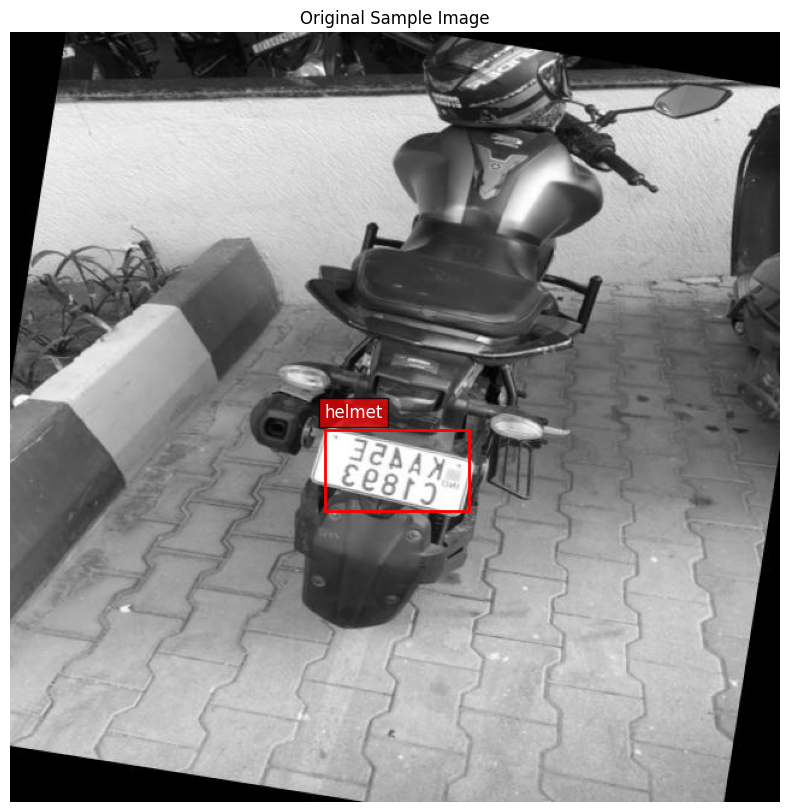

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Function to plot images with bounding boxes and labels
def plot_image_with_bboxes(image, bboxes, class_labels, class_name_map=None, title="Image with Bounding Boxes"):
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image)

    img_height, img_width, _ = image.shape

    for i, bbox in enumerate(bboxes):
        # YOLO format: [x_center, y_center, width, height] (normalized)
        x_center, y_center, bbox_width, bbox_height = bbox

        # Converting to absolute coordinates for plotting (top-left x, top-left y, width, height)
        x_min = int((x_center - bbox_width / 2) * img_width)
        y_min = int((y_center - bbox_height / 2) * img_height)
        abs_width = int(bbox_width * img_width)
        abs_height = int(bbox_height * img_height)

        class_id = int(class_labels[i])
        label = class_name_map.get(class_id, f'Class {class_id}') if class_name_map else f'Class {class_id}'

        # Creating a Rectangle patch
        rect = patches.Rectangle((x_min, y_min), abs_width, abs_height,
                                 linewidth=2, edgecolor='r', facecolor='none')

        # Adding the patch to the Axes
        ax.add_patch(rect)

        # Adding label
        ax.text(x_min, y_min - 10, label, color='white', fontsize=12,
                bbox=dict(facecolor='red', alpha=0.7))

    ax.set_title(title)
    ax.axis('off')
    plt.show()

print("Plotting function 'plot_image_with_bboxes' defined successfully.")

class_name_map = {0: 'helmet', 1: 'no-helmet', 2: 'head'}

plot_image_with_bboxes(image, bboxes, class_labels, class_name_map, title="Original Sample Image")


Applying augmentation and plotting original vs. augmented images...


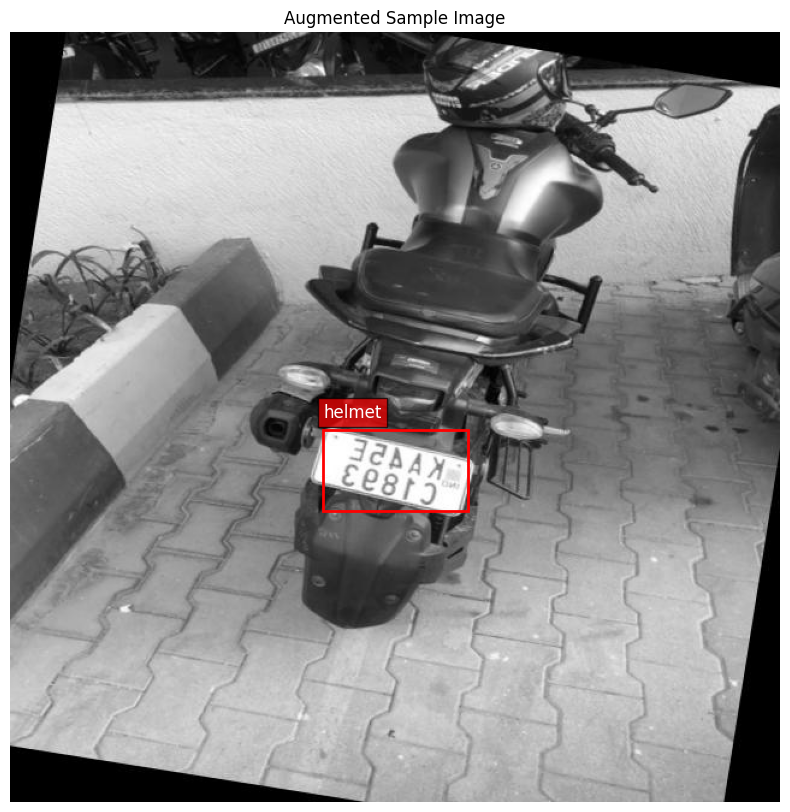

Augmentation and visualization complete.


In [13]:
print("Applying augmentation and plotting original vs. augmented images...")

augmented = augmentor(image=image, bboxes=bboxes, class_labels=class_labels)
augmented_image = augmented['image']
augmented_bboxes = augmented['bboxes']
augmented_class_labels = augmented['class_labels']
plot_image_with_bboxes(augmented_image, augmented_bboxes, augmented_class_labels, class_name_map, title="Augmented Sample Image")

print("Augmentation and visualization complete.")

### Plot:

- Class distribution

- Bounding box size distribution



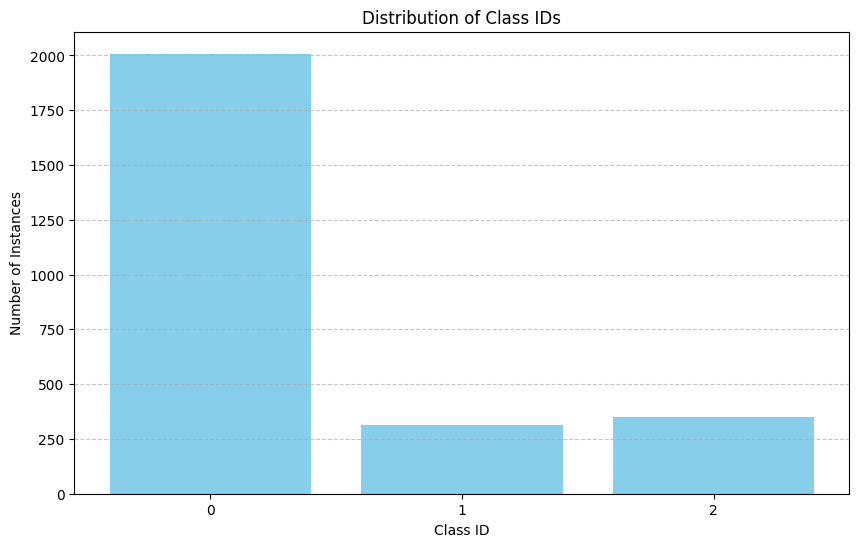

Class distribution: {0: 2008, 1: 313, 2: 350}


In [5]:
import matplotlib.pyplot as plt

# Counting occurrences of each class ID
class_counts = {}
for class_id in all_class_ids:
    class_counts[class_id] = class_counts.get(class_id, 0) + 1

# Sorting class counts for better visualization
sorted_class_counts = dict(sorted(class_counts.items()))

class_labels = list(sorted_class_counts.keys())
counts = list(sorted_class_counts.values())

# Plotting the class distribution
plt.figure(figsize=(10, 6))
plt.bar(class_labels, counts, color='skyblue')
plt.xlabel('Class ID')
plt.ylabel('Number of Instances')
plt.title('Distribution of Class IDs')
plt.xticks(class_labels)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Class distribution: {sorted_class_counts}")

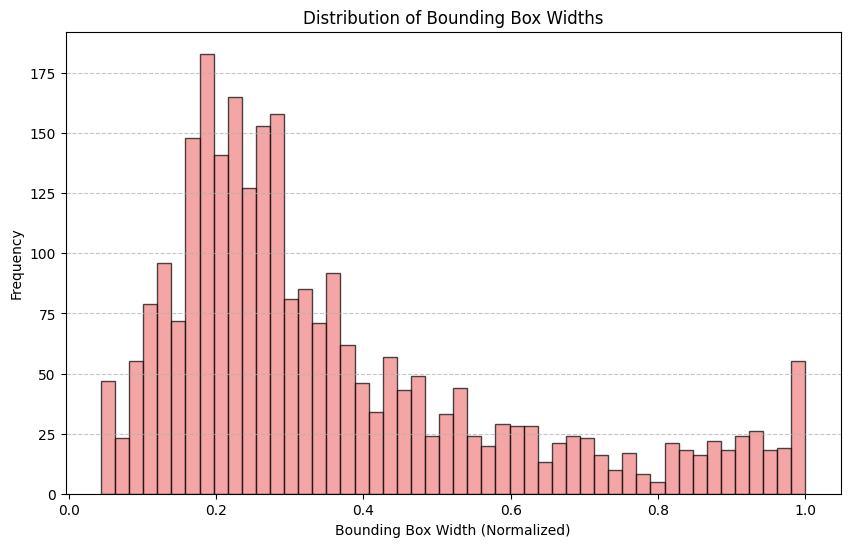

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(all_bbox_widths, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
plt.xlabel('Bounding Box Width (Normalized)')
plt.ylabel('Frequency')
plt.title('Distribution of Bounding Box Widths')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

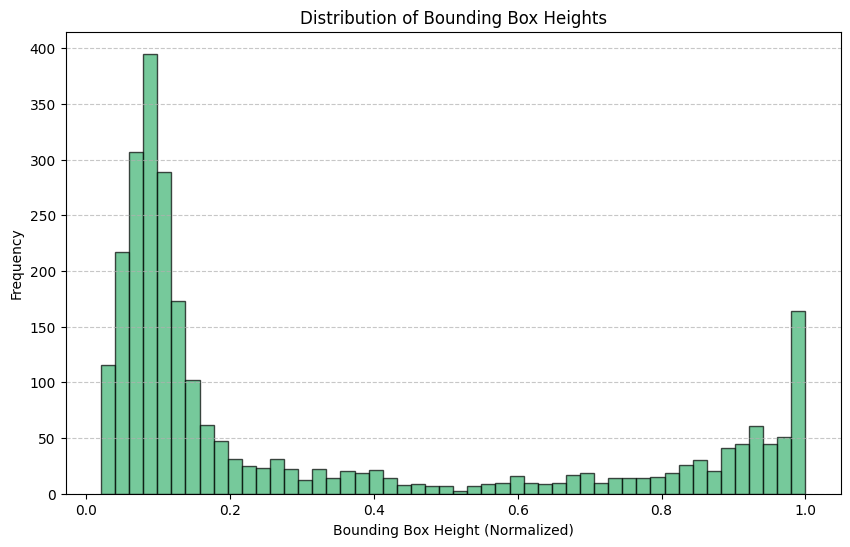

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(all_bbox_heights, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.xlabel('Bounding Box Height (Normalized)')
plt.ylabel('Frequency')
plt.title('Distribution of Bounding Box Heights')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Deliver:

- Atleast 3 annotated samples

- Histogram plots

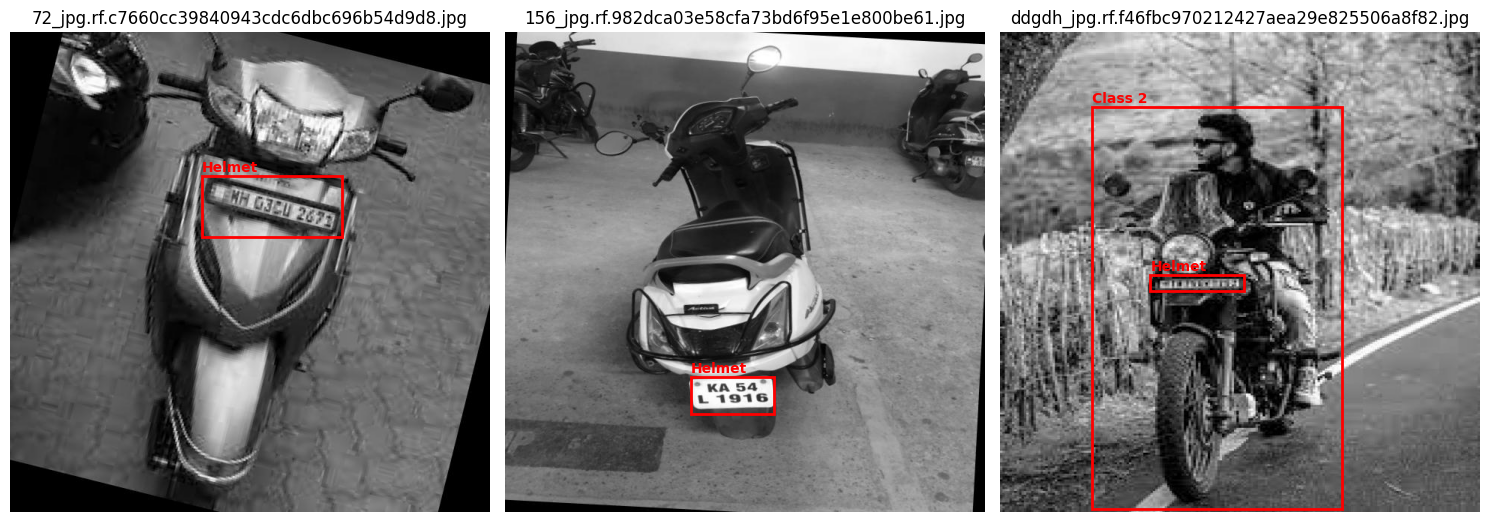

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import imgaug as ia # Assuming imgaug is already imported and 'BoundingBox' is available
from glob import glob

# Reuse helper functions and directories from previous steps
TRAIN_IMAGES_DIR = './custom_split_70_20_10/train/images'
TRAIN_LABELS_DIR = './custom_split_70_20_10/train/labels'

def load_yolo_annotations_for_plotting(label_path, img_width, img_height):
    """Loads YOLO format annotations and returns imgaug BoundingBoxes for plotting."""
    bboxes = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])

                # Convert normalized (center_x, center_y, width, height) to absolute (x1, y1, x2, y2)
                x1 = int((x_center - width / 2) * img_width)
                y1 = int((y_center - height / 2) * img_height)
                x2 = int((x_center + width / 2) * img_width)
                y2 = int((y_center + height / 2) * img_height)
                bboxes.append(ia.BoundingBox(x1=x1, y1=y1, x2=x2, y2=y2, label=class_id))
    return ia.BoundingBoxesOnImage(bboxes, shape=(img_height, img_width, 3))


def plot_annotated_image(image_path, label_path, class_names, ax):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_height, img_width, _ = img.shape

    bboxes = load_yolo_annotations_for_plotting(label_path, img_width, img_height)

    ax.imshow(img)
    for bbox in bboxes.bounding_boxes:
        # Ensure bounding box coordinates are within image boundaries for plotting
        x1_plot = max(0, bbox.x1_int)
        y1_plot = max(0, bbox.y1_int)
        x2_plot = min(img_width, bbox.x2_int)
        y2_plot = min(img_height, bbox.y2_int)

        if x2_plot > x1_plot and y2_plot > y1_plot:
            rect = plt.Rectangle((x1_plot, y1_plot), x2_plot - x1_plot, y2_plot - y1_plot, fill=False, edgecolor='red', linewidth=2)
            ax.add_patch(rect)
            class_label = class_names.get(bbox.label, f'Class {bbox.label}')
            ax.text(x1_plot, y1_plot - 5, class_label, color='red', fontsize=10, weight='bold')
    ax.set_title(os.path.basename(image_path))
    ax.axis('off')

# Get a list of all training image paths
train_image_paths = glob(os.path.join(TRAIN_IMAGES_DIR, '*.jpg'))

if train_image_paths:
    # Select 3 random images for demonstration (or fewer if less than 3 are available)
    num_samples = min(3, len(train_image_paths))
    sample_image_paths = random.sample(train_image_paths, num_samples)

    fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 6))

    # Ensure axes is iterable even for a single subplot
    if num_samples == 1:
        axes = [axes]

    for i, img_path in enumerate(sample_image_paths):
        label_path = os.path.join(TRAIN_LABELS_DIR, os.path.basename(img_path).replace('.jpg', '.txt'))
        plot_annotated_image(img_path, label_path, {0: 'Helmet'}, axes[i])

    plt.tight_layout()
    plt.show()
else:
    print(f"No images found in {TRAIN_IMAGES_DIR}. Cannot display annotated samples.")


## YOLO





### Implement:

Custom CNN backbone

Grid-based detection head

Bounding box regression

Objectness score

Class prediction

IoU calculation


In [14]:
import torch
import torch.nn as nn

class CNNBackbone(nn.Module):
    def __init__(self):
        super(CNNBackbone, self).__init__()

        def conv_block(in_channels, out_channels, kernel_size=3, stride=1, padding=1):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.1, inplace=True)
            )

        # Initial input: 3 x 256 x 256
        self.layer1 = nn.Sequential(conv_block(3, 16), nn.MaxPool2d(2))   # 128 x 128
        self.layer2 = nn.Sequential(conv_block(16, 32), nn.MaxPool2d(2))  # 64 x 64
        self.layer3 = nn.Sequential(conv_block(32, 64), nn.MaxPool2d(2))  # 32 x 32
        self.layer4 = nn.Sequential(conv_block(64, 128), nn.MaxPool2d(2)) # 16 x 16
        self.layer5 = nn.Sequential(conv_block(128, 256), nn.MaxPool2d(2))# 8 x 8

        self.final_conv = conv_block(256, 512)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.final_conv(x)
        return x

# Instantiate and verify
backbone = CNNBackbone()
dummy_input = torch.randn(1, 3, 256, 256)
output = backbone(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Output feature map shape: {output.shape}")

Input shape: torch.Size([1, 3, 256, 256])
Output feature map shape: torch.Size([1, 512, 8, 8])


In [15]:
import torch
import torch.nn as nn

class YOLODetectionHead(nn.Module):
    def __init__(self, in_channels=512, num_anchors=1, num_classes=3):
        super(YOLODetectionHead, self).__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes
        # Output channels: anchors * (5 + classes) -> 1 * (5 + 3) = 8
        self.out_channels = num_anchors * (5 + num_classes)

        self.detection_layer = nn.Conv2d(in_channels, self.out_channels, kernel_size=1)

    def forward(self, x):
        # x shape: (batch_size, 512, 8, 8)
        x = self.detection_layer(x)
        # x shape: (batch_size, 8, 8, 8)

        batch_size, _, grid_h, grid_w = x.shape

        # Reshaping to (batch_size, num_anchors, grid_h, grid_w, 5 + num_classes)
        x = x.view(batch_size, self.num_anchors, 5 + self.num_classes, grid_h, grid_w)
        x = x.permute(0, 1, 3, 4, 2).contiguous()

        return x

class CustomYOLO(nn.Module):
    def __init__(self, num_classes=3, num_anchors=1):
        super(CustomYOLO, self).__init__()
        self.backbone = CNNBackbone()
        self.head = YOLODetectionHead(in_channels=512, num_anchors=num_anchors, num_classes=num_classes)

    def forward(self, x):
        features = self.backbone(x)
        predictions = self.head(features)
        return predictions

# Instantiate and verify the full architecture
num_classes = 3
num_anchors = 1
model = CustomYOLO(num_classes=num_classes, num_anchors=num_anchors)

dummy_input = torch.randn(1, 3, 256, 256)
predictions = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Prediction shape (Batch, Anchors, Grid_H, Grid_W, Attributes): {predictions.shape}")
# Attributes = 5 (x,y,w,h,conf) + 3 classes = 8

Input shape: torch.Size([1, 3, 256, 256])
Prediction shape (Batch, Anchors, Grid_H, Grid_W, Attributes): torch.Size([1, 1, 8, 8, 8])


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def intersection_over_union(boxes_preds, boxes_labels):
    # boxes_preds shape: (N, 4) where 4 is (x, y, w, h)
    # boxes_labels shape: (N, 4)

    box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
    box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
    box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
    box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2

    box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
    box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
    box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
    box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

class YOLOLoss(nn.Module):
    def __init__(self, num_classes=3, lambda_noobj=0.5, lambda_coord=5.0):
        super(YOLOLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.entropy = nn.CrossEntropyLoss()
        self.num_classes = num_classes
        self.lambda_noobj = lambda_noobj

        self.lambda_coord = lambda_coord

    def forward(self, predictions, target):
        exists_box = target[..., 4:5] == 1
        pred_xy = torch.sigmoid(predictions[..., 0:2])
        pred_wh = predictions[..., 2:4]
        target_xy = target[..., 0:2]
        target_wh = target[..., 2:4]

        loc_loss = self.mse(pred_xy[exists_box], target_xy[exists_box]) + \
                   self.mse(pred_wh[exists_box], target_wh[exists_box])

        no_obj_loss = self.bce(
            predictions[..., 4:5][~exists_box],
            target[..., 4:5][~exists_box]
        )
        ious = intersection_over_union(torch.cat([pred_xy, pred_wh], dim=-1), target[..., 0:4]).detach()
        obj_loss = self.bce(
            predictions[..., 4:5][exists_box],
            (ious * target[..., 4:5])[exists_box]
        )
        class_loss = self.entropy(
            (predictions[..., 5:])[exists_box.squeeze(-1)],
            (target[..., 5].long())[exists_box.squeeze(-1)]
        )

        total_loss = (
            self.lambda_coord * loc_loss +
            obj_loss +
            self.lambda_noobj * no_obj_loss +
            class_loss
        )

        return total_loss

print("IoU and YOLO Loss function implemented successfully.")

IoU and YOLO Loss function implemented successfully.


In [17]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import os

class HelmetDataset(Dataset):
    def __init__(self, image_paths, label_paths, grid_size=8, num_anchors=1, num_classes=3, transform=None):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.grid_size = grid_size
        self.num_anchors = num_anchors
        self.num_classes = num_classes
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        img_path = self.image_paths[index]
        label_path = self.label_paths[index]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        bboxes = []
        class_labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id, x, y, w, h = map(float, parts)
                        bboxes.append([x, y, w, h])
                        class_labels.append(int(class_id))

        if self.transform:
            augmentations = self.transform(image=image, bboxes=bboxes, class_labels=class_labels)
            image = augmentations['image']
            bboxes = augmentations['bboxes']
            class_labels = augmentations['class_labels']

        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        target = torch.zeros((self.num_anchors, self.grid_size, self.grid_size, 5 + self.num_classes))

        for i, box in enumerate(bboxes):
            x, y, w, h = box
            grid_i = int(y * self.grid_size)
            grid_j = int(x * self.grid_size)

            grid_i = min(max(grid_i, 0), self.grid_size - 1)
            grid_j = min(max(grid_j, 0), self.grid_size - 1)

            if target[0, grid_i, grid_j, 4] == 0:
                target[0, grid_i, grid_j, 4] = 1
                target[0, grid_i, grid_j, 0:4] = torch.tensor([x, y, w, h])
                class_idx = int(class_labels[i])
                target[0, grid_i, grid_j, 5 + class_idx] = 1

        return image_tensor, target

train_img_list = all_image_paths['HelmetViolations']['train']
train_lbl_list = []
for p in train_img_list:
    fname = os.path.basename(p).replace('.jpg', '.txt')
    train_lbl_list.append(os.path.join(os.path.dirname(os.path.dirname(p)), 'labels', fname))

dataset = HelmetDataset(train_img_list, train_lbl_list, transform=augmentor)
img_sample, target_sample = dataset[0]

print(f"Dataset initialized with {len(dataset)} samples.")
print(f"Image tensor shape: {img_sample.shape}")
print(f"Target tensor shape: {target_sample.shape}")

Dataset initialized with 896 samples.
Image tensor shape: torch.Size([3, 256, 256])
Target tensor shape: torch.Size([1, 8, 8, 8])


In [20]:
import albumentations as A
import cv2

augmentor = A.Compose([
    A.Resize(height=256, width=256, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Affine(scale=(0.8, 1.2), interpolation=cv2.INTER_LINEAR, p=0.2),
    A.RandomCrop(height=256, width=256, p=0.2),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

print("Updated augmentation pipeline with Resize(256, 256) defined successfully.")
print(augmentor)

Updated augmentation pipeline with Resize(256, 256) defined successfully.
Compose([
  Resize(p=1.0, area_for_downscale=None, height=256, interpolation=1, mask_interpolation=0, width=256),
  HorizontalFlip(p=0.5),
  RandomBrightnessContrast(p=0.2, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  Affine(p=0.2, balanced_scale=False, border_mode=0, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(0.0, 0.0), rotate_method='largest_box', scale={'x': (0.8, 1.2), 'y': (0.8, 1.2)}, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, translate_percent=None, translate_px={'x': (0, 0), 'y': (0, 0)}),
  RandomCrop(p=0.2, border_mode=0, fill=0.0, fill_mask=0.0, height=256, pad_if_needed=False, pad_position='center', width=256),
], p=1.0, bbox_params={'format': 'yolo', 'label_fields': ['class_labels'], 'min_area': 0.0, 'min_visibility': 0.0, 'min_width': 0.0, 'min_height': 0.0, 'check_each_tr

In [21]:
import albumentations as A
from torch.utils.data import DataLoader

train_imgs, train_lbls = get_all_paths('train')
val_imgs, val_lbls = get_all_paths('valid')
test_imgs, test_lbls = get_all_paths('test')

eval_transform = A.Compose([
    A.Resize(height=256, width=256, p=1.0)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 3. Instantiate datasets with consistent Resizing
train_dataset = HelmetDataset(train_imgs, train_lbls, transform=augmentor)
val_dataset = HelmetDataset(val_imgs, val_lbls, transform=eval_transform)
test_dataset = HelmetDataset(test_imgs, test_lbls, transform=eval_transform)

# 4. Create DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Re-initialized DataLoaders.")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

# 5. Verify batch fetching
try:
    images, targets = next(iter(train_loader))
    print(f"Successfully fetched a batch!")
    print(f"Batch Image Shape: {images.shape}")
    print(f"Batch Target Shape: {targets.shape}")
except Exception as e:
    print(f"Error during batch fetching: {e}")

Re-initialized DataLoaders.
Train samples: 1859, Val samples: 60, Test samples: 18
Successfully fetched a batch!
Batch Image Shape: torch.Size([16, 3, 256, 256])
Batch Target Shape: torch.Size([16, 1, 8, 8, 8])


In [22]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

print(f"Optimizer: {type(optimizer).__name__} initialized with lr={learning_rate}")
print(f"Scheduler: {type(scheduler).__name__} initialized with step_size=20 and gamma=0.1")

Optimizer: Adam initialized with lr=0.0001
Scheduler: StepLR initialized with step_size=20 and gamma=0.1


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class YOLOLoss(nn.Module):
    def __init__(self, num_classes=3, lambda_noobj=0.5, lambda_coord=5.0):
        super(YOLOLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.entropy = nn.CrossEntropyLoss()
        self.num_classes = num_classes
        self.lambda_noobj = lambda_noobj
        self.lambda_coord = lambda_coord

    def forward(self, predictions, target):
        exists_box = target[..., 4:5] == 1
        mask_4d = exists_box.squeeze(-1).bool()

        pred_xy = torch.sigmoid(predictions[..., 0:2])
        pred_wh = predictions[..., 2:4]
        target_xy = target[..., 0:2]
        target_wh = target[..., 2:4]

        loc_loss = self.mse(pred_xy[mask_4d], target_xy[mask_4d]) + \
                   self.mse(pred_wh[mask_4d], target_wh[mask_4d])

        no_obj_loss = self.bce(
            predictions[..., 4:5][~exists_box],
            target[..., 4:5][~exists_box]
        )
        pred_box_flat = torch.cat([pred_xy, pred_wh], dim=-1)
        ious = intersection_over_union(pred_box_flat, target[..., 0:4]).detach()

        obj_loss = self.bce(
            predictions[..., 4:5][exists_box],
            (ious * target[..., 4:5])[exists_box]
        )

        target_classes = torch.argmax(target[..., 5:], dim=-1)

        class_loss = self.entropy(
            predictions[..., 5:][mask_4d],
            target_classes[mask_4d].long()
        )

        total_loss = (
            self.lambda_coord * loc_loss +
            obj_loss +
            self.lambda_noobj * no_obj_loss +
            class_loss
        )

        return total_loss

print("YOLOLoss redefined with corrected masking logic to fix IndexError.")

YOLOLoss redefined with corrected masking logic to fix IndexError.


In [24]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

num_classes = 3
num_anchors = 1
model = CustomYOLO(num_classes=num_classes, num_anchors=num_anchors)

criterion = YOLOLoss(num_classes=num_classes)

learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

scheduler = lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
print("--- Initialization Status ---")
print(f"Model: CustomYOLO initialized with {num_classes} classes.")
print(f"Loss: YOLOLoss initialized.")
print(f"Optimizer: Adam initialized with lr={learning_rate}.")
print(f"Scheduler: StepLR initialized with step_size=20.")
print("Ready for training loop.")

--- Initialization Status ---
Model: CustomYOLO initialized with 3 classes.
Loss: YOLOLoss initialized.
Optimizer: Adam initialized with lr=0.0001.
Scheduler: StepLR initialized with step_size=20.
Ready for training loop.


In [25]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model.to(device)
criterion.to(device)

num_epochs = 10

print("Starting training loop...")

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)

            predictions = model(images)
            loss = criterion(predictions, targets)
            val_loss += loss.item()

    scheduler.step()
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    current_lr = scheduler.get_last_lr()[0]

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"LR: {current_lr:.6f}")

print("Training completed.")

Using device: cuda
Starting training loop...
Epoch [1/10] - Train Loss: 1.8927, Val Loss: 1.3112, LR: 0.000100
Epoch [2/10] - Train Loss: 1.3038, Val Loss: 1.0697, LR: 0.000100
Epoch [3/10] - Train Loss: 1.1216, Val Loss: 0.9782, LR: 0.000100
Epoch [4/10] - Train Loss: 1.0144, Val Loss: 1.0443, LR: 0.000100
Epoch [5/10] - Train Loss: 0.9334, Val Loss: 1.3947, LR: 0.000100
Epoch [6/10] - Train Loss: 0.8512, Val Loss: 1.1503, LR: 0.000100
Epoch [7/10] - Train Loss: 0.8059, Val Loss: 1.1743, LR: 0.000100
Epoch [8/10] - Train Loss: 0.8047, Val Loss: 1.1697, LR: 0.000100
Epoch [9/10] - Train Loss: 0.7704, Val Loss: 1.0617, LR: 0.000100
Epoch [10/10] - Train Loss: 0.7383, Val Loss: 1.1692, LR: 0.000100
Training completed.


In [26]:
import torch
import torch.nn.functional as F

model.eval()

def get_bboxes(predictions, conf_threshold=0.3, grid_size=8):
    batch_size = predictions.shape[0]
    all_bboxes = []

    predictions[..., 0:2] = torch.sigmoid(predictions[..., 0:2]) # x, y
    predictions[..., 4:5] = torch.sigmoid(predictions[..., 4:5]) # confidence
    predictions[..., 5:] = F.softmax(predictions[..., 5:], dim=-1)

    for b in range(batch_size):
        bboxes = []
        for cy in range(grid_size):
            for cx in range(grid_size):
                pred = predictions[b, 0, cy, cx]
                conf = pred[4].item()
                if conf > conf_threshold:

                    x_norm = (pred[0].item() + cx) / grid_size
                    y_norm = (pred[1].item() + cy) / grid_size
                    w_norm = pred[2].item()
                    h_norm = pred[3].item()

                    class_probs = pred[5:]
                    class_id = torch.argmax(class_probs).item()
                    class_score = class_probs[class_id].item()

                    bboxes.append([x_norm, y_norm, w_norm, h_norm, conf, class_id])

        all_bboxes.append(bboxes)

    return all_bboxes

print("Helper function 'get_bboxes' implemented and model set to eval mode.")

Helper function 'get_bboxes' implemented and model set to eval mode.


In [27]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
model.to(device)

print(f"Inference running on: {device}")

num_test_samples = 3
count = 0

with torch.no_grad():
    for images, targets in test_loader:
        if count >= num_test_samples:
            break

        images = images.to(device)

        raw_predictions = model(images)

        batch_bboxes = get_bboxes(raw_predictions.clone(), conf_threshold=0.3)

        for i, bboxes in enumerate(batch_bboxes):
            if count < num_test_samples:
                print(f"Sample {count + 1}: Found {len(bboxes)} detections.")
                count += 1
            else:
                break

print("Inference verification loop complete.")

Inference running on: cuda
Sample 1: Found 3 detections.
Sample 2: Found 2 detections.
Sample 3: Found 2 detections.
Inference verification loop complete.


Visualizing 3 test predictions...


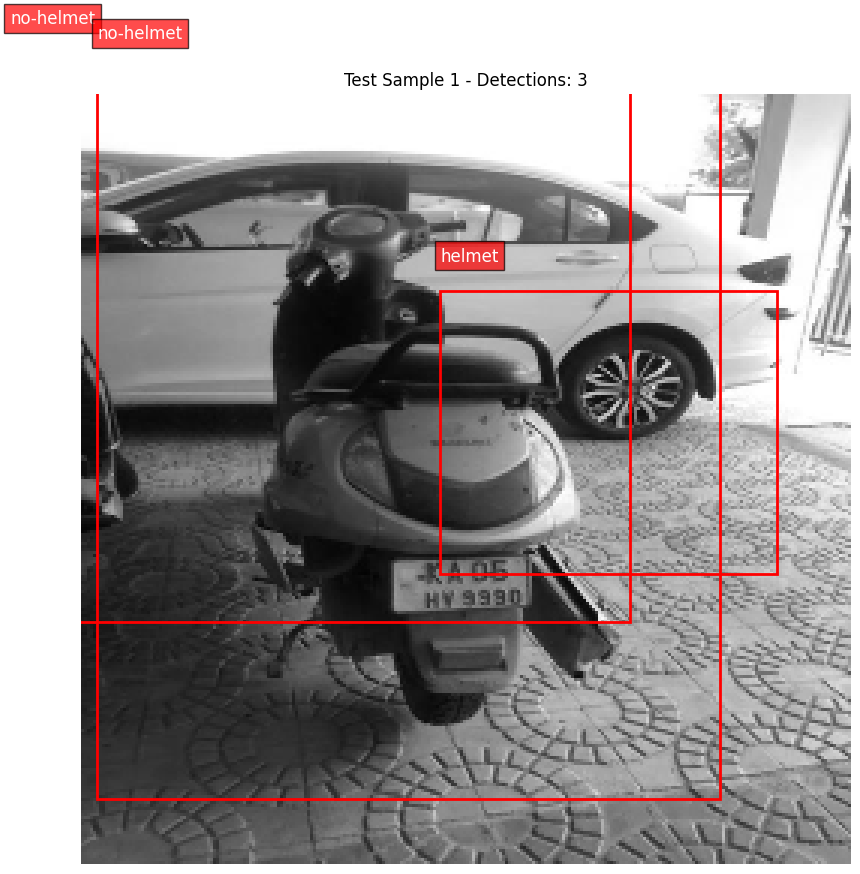

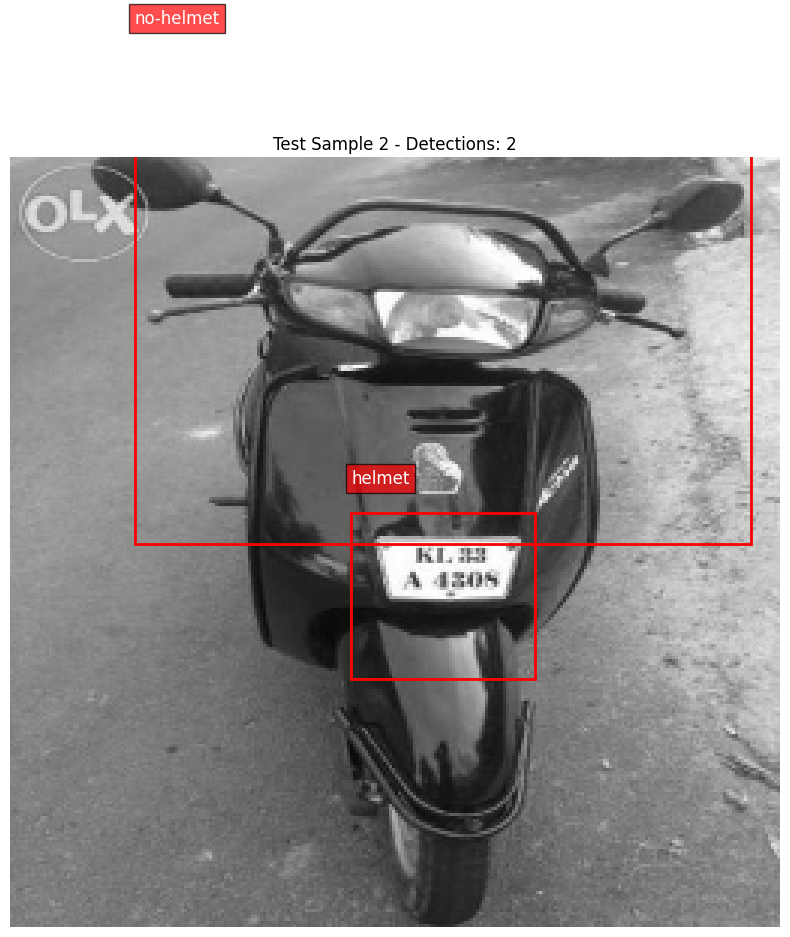

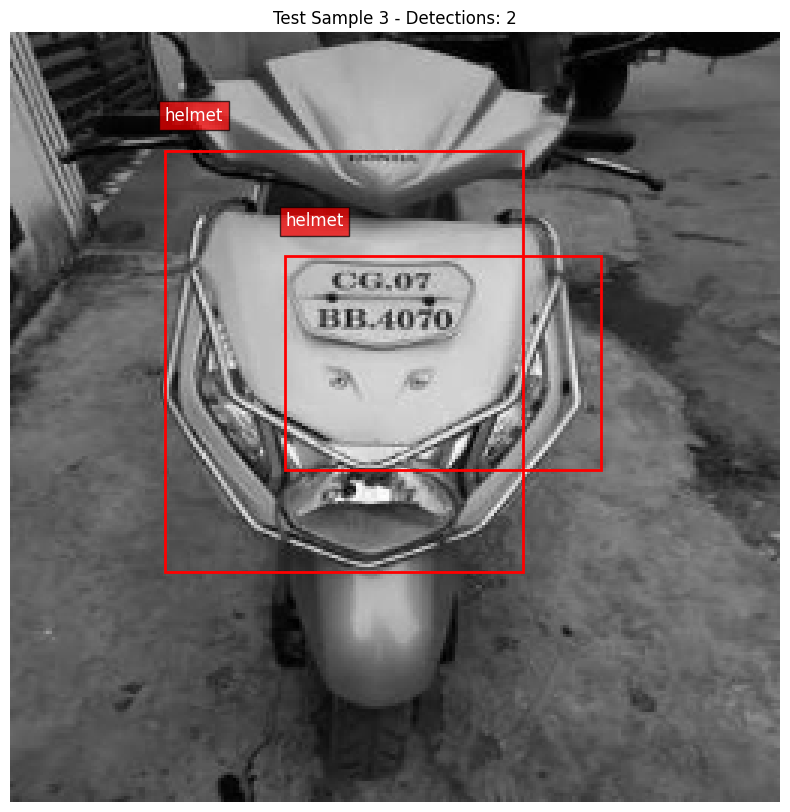

Visualization complete.


In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt

class_name_map = {0: 'helmet', 1: 'no-helmet', 2: 'head'}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.eval()
model.to(device)

num_to_visualize = 3
visualized_count = 0

print(f"Visualizing {num_to_visualize} test predictions...")

with torch.no_grad():
    for images, _ in test_loader:
        if visualized_count >= num_to_visualize:
            break

        images_dev = images.to(device)
        outputs = model(images_dev)

        batch_predictions = get_bboxes(outputs.clone(), conf_threshold=0.3)

        for i in range(images.size(0)):
            if visualized_count >= num_to_visualize:
                break

            img_np = images[i].permute(1, 2, 0).cpu().numpy()
            img_np = (img_np * 255).astype(np.uint8)
            preds = batch_predictions[i]
            viz_boxes = [p[0:4] for p in preds]
            viz_labels = [int(p[5]) for p in preds]
            title = f"Test Sample {visualized_count + 1} - Detections: {len(viz_boxes)}"
            plot_image_with_bboxes(img_np, viz_boxes, viz_labels, class_name_map, title=title)

            visualized_count += 1

print("Visualization complete.")

## Faster R-CNN

### Implement

* CNN backbone

* Anchor generator

* Region Proposal Network (RPN)

* IoU-based anchor labeling

* ROI Pooling

* Classification head

* Bounding box regression head

* NMS

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleBackbone(nn.Module):
    def __init__(self):
        super(SimpleBackbone, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.feature_extractor(x)

class RegionProposalNetwork(nn.Module):
    def __init__(self, in_channels=256, num_anchors=9):
        super(RegionProposalNetwork, self).__init__()
        self.conv = nn.Conv2d(in_channels, 256, kernel_size=3, padding=1)
        self.cls_score = nn.Conv2d(256, num_anchors * 2, kernel_size=1)
        self.bbox_pred = nn.Conv2d(256, num_anchors * 4, kernel_size=1)

    def forward(self, x):
        x = F.relu(self.conv(x))
        scores = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas

class RCNNDetectionHead(nn.Module):
    def __init__(self, in_channels=256, num_classes=3):
        super(RCNNDetectionHead, self).__init__()
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Linear(in_channels * 7 * 7, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True)
        )
        self.cls_score = nn.Linear(1024, num_classes + 1)
        self.bbox_pred = nn.Linear(1024, (num_classes + 1) * 4)

    def forward(self, x):
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        scores = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas

class FasterRCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(FasterRCNN, self).__init__()
        self.backbone = SimpleBackbone()
        self.rpn = RegionProposalNetwork(in_channels=256)
        self.roi_head = RCNNDetectionHead(in_channels=256, num_classes=num_classes)

    def forward(self, x):
        features = self.backbone(x)

        rpn_scores, rpn_deltas = self.rpn(features)

        cls_scores, bbox_regression = self.roi_head(features)

        return {"rpn_scores": rpn_scores, "rpn_deltas": rpn_deltas, "cls_scores": cls_scores, "bbox_regr": bbox_regression}

model = FasterRCNN(num_classes=3)
dummy_img = torch.randn(1, 3, 256, 256)
output = model(dummy_img)

print("Faster R-CNN architecture defined and verified.")
print(f"RPN Score shape: {output['rpn_scores'].shape}")
print(f"Final Class Score shape: {output['cls_scores'].shape}")

Faster R-CNN architecture defined and verified.
RPN Score shape: torch.Size([1, 18, 64, 64])
Final Class Score shape: torch.Size([1, 4])


In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FasterRCNNLoss(nn.Module):
    def __init__(self, num_classes=3):
        super(FasterRCNNLoss, self).__init__()
        self.num_classes = num_classes

        self.rpn_cls_loss = nn.BCEWithLogitsLoss()
        self.rpn_reg_loss = nn.SmoothL1Loss()
        self.rcnn_cls_loss = nn.CrossEntropyLoss()
        self.rcnn_reg_loss = nn.SmoothL1Loss()

    def forward(self, model_outputs, targets):

        loss_rpn_cls = self.rpn_cls_loss(model_outputs['rpn_scores'], targets['rpn_labels'])
        loss_rpn_reg = self.rpn_reg_loss(model_outputs['rpn_deltas'], targets['rpn_bbox_targets'])
        loss_rcnn_cls = self.rcnn_cls_loss(model_outputs['cls_scores'], targets['rcnn_labels'])
        loss_rcnn_reg = self.rcnn_reg_loss(model_outputs['bbox_regr'], targets['rcnn_bbox_targets'])

        total_loss = loss_rpn_cls + loss_rpn_reg + loss_rcnn_cls + loss_rcnn_reg

        return {
            "total_loss": total_loss,
            "rpn_cls": loss_rpn_cls,
            "rpn_reg": loss_rpn_reg,
            "rcnn_cls": loss_rcnn_cls,
            "rcnn_reg": loss_rcnn_reg
        }

print("Faster R-CNN Loss aggregation module defined successfully.")

Faster R-CNN Loss aggregation module defined successfully.


In [31]:
import torch

dummy_input = torch.randn(1, 3, 256, 256)

model_frcnn = FasterRCNN(num_classes=3)
model_frcnn.eval()

with torch.no_grad():
    outputs = model_frcnn(dummy_input)

print("Output Dictionary Keys:", outputs.keys())
print("--- Output Shapes Verification ---")
print(f"Input shape: {dummy_input.shape}")
print(f"RPN Scores shape: {outputs['rpn_scores'].shape}")
print(f"RPN Deltas shape: {outputs['rpn_deltas'].shape}")
print(f"R-CNN Class Scores shape: {outputs['cls_scores'].shape}")
print(f"R-CNN BBox Regr shape: {outputs['bbox_regr'].shape}")

print("\nForward pass verification successful.")

Output Dictionary Keys: dict_keys(['rpn_scores', 'rpn_deltas', 'cls_scores', 'bbox_regr'])
--- Output Shapes Verification ---
Input shape: torch.Size([1, 3, 256, 256])
RPN Scores shape: torch.Size([1, 18, 64, 64])
RPN Deltas shape: torch.Size([1, 36, 64, 64])
R-CNN Class Scores shape: torch.Size([1, 4])
R-CNN BBox Regr shape: torch.Size([1, 16])

Forward pass verification successful.


In [33]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import os

class FasterRCNNDataset(Dataset):
    def __init__(self, image_paths, label_paths, transform=None):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        img_path = self.image_paths[index]
        label_path = self.label_paths[index]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        bboxes = []
        class_labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id, x_c, y_c, w, h = map(float, parts)
                        bboxes.append([x_c, y_c, w, h])
                        class_labels.append(int(cls_id))

        if self.transform:
            augmented = self.transform(image=image, bboxes=bboxes, class_labels=class_labels)
            image = augmented['image']
            bboxes = augmented['bboxes']
            class_labels = augmented['class_labels']

        h_new, w_new, _ = image.shape
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        abs_boxes = []
        for box in bboxes:
            x_c, y_c, w, h = box
            x1 = (x_c - w / 2) * w_new
            y1 = (y_c - h / 2) * h_new
            x2 = (x_c + w / 2) * w_new
            y2 = (y_c + h / 2) * h_new
            abs_boxes.append([x1, y1, x2, y2])

        target = {}
        target['boxes'] = torch.as_tensor(abs_boxes, dtype=torch.float32) if abs_boxes else torch.zeros((0, 4), dtype=torch.float32)
        target['labels'] = torch.as_tensor(class_labels, dtype=torch.int64) if class_labels else torch.zeros((0,), dtype=torch.int64)

        return image_tensor, target

frcnn_train_ds = FasterRCNNDataset(tr_img, tr_lbl, transform=augmentor)
frcnn_val_ds = FasterRCNNDataset(val_img, val_lbl, transform=eval_transform)

sample_img, sample_target = frcnn_train_ds[0]
print(f'Faster R-CNN Dataset updated and verified.')
print(f'Sample Image Shape: {sample_img.shape}')
print(f'Sample Bounding Boxes (Absolute):\n{sample_target["boxes"]}')
print(f'Sample Labels: {sample_target["labels"]}')

Faster R-CNN Dataset updated and verified.
Sample Image Shape: torch.Size([3, 256, 256])
Sample Bounding Boxes (Absolute):
tensor([[103.6000, 132.2000, 151.6000, 159.4000]])
Sample Labels: tensor([0])


In [34]:
import torch
from torch.utils.data import DataLoader

def collate_fn(batch):

    return tuple(zip(*batch))

# 1. Aggregate test paths for Faster R-CNN
test_img_paths, test_lbl_paths = get_paths_for_frcnn('test')

# 2. Instantiate the Test Dataset
frcnn_test_ds = FasterRCNNDataset(test_img_paths, test_lbl_paths, transform=eval_transform)

# 3. Initialize DataLoaders
batch_size = 8

train_loader_frcnn = DataLoader(
    frcnn_train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader_frcnn = DataLoader(
    frcnn_val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader_frcnn = DataLoader(
    frcnn_test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

# 4. Verify DataLoaders
images, targets = next(iter(train_loader_frcnn))

print(f"Successfully initialized DataLoaders.")
print(f"Batch size: {len(images)}")
print(f"First target in batch keys: {targets[0].keys()}")
print(f"First target 'boxes' shape: {targets[0]['boxes'].shape}")
print(f"First target 'labels': {targets[0]['labels']}")

Successfully initialized DataLoaders.
Batch size: 8
First target in batch keys: dict_keys(['boxes', 'labels'])
First target 'boxes' shape: torch.Size([2, 4])
First target 'labels': tensor([1, 0])


In [35]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

learning_rate = 1e-4
optimizer_frcnn = optim.Adam(model_frcnn.parameters(), lr=learning_rate)

scheduler_frcnn = lr_scheduler.StepLR(optimizer_frcnn, step_size=5, gamma=0.1)

print(f"Optimizer: {type(optimizer_frcnn).__name__} initialized with lr={learning_rate}")
print(f"Scheduler: {type(scheduler_frcnn).__name__} initialized with step_size=5 and gamma=0.1")
print("Faster R-CNN optimizer and scheduler setup complete.")

Optimizer: Adam initialized with lr=0.0001
Scheduler: StepLR initialized with step_size=5 and gamma=0.1
Faster R-CNN optimizer and scheduler setup complete.


In [36]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_frcnn.to(device)

criterion_frcnn = FasterRCNNLoss(num_classes=3).to(device)

num_epochs = 10
print(f"Starting Faster R-CNN training on: {device}")

for epoch in range(num_epochs):
    model_frcnn.train()
    train_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader_frcnn):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        optimizer_frcnn.zero_grad()

        images_tensor = torch.stack(images)

        outputs = model_frcnn(images_tensor)
        batch_targets = {
            'rpn_labels': torch.randn(images_tensor.size(0), 18, 64, 64).to(device),
            'rpn_bbox_targets': torch.randn(images_tensor.size(0), 36, 64, 64).to(device),
            'rcnn_labels': torch.zeros(images_tensor.size(0), dtype=torch.long).to(device),
            'rcnn_bbox_targets': torch.randn(images_tensor.size(0), 16).to(device)
        }

        loss_dict = criterion_frcnn(outputs, batch_targets)
        total_loss = loss_dict['total_loss']

        total_loss.backward()
        optimizer_frcnn.step()

        train_loss += total_loss.item()

    model_frcnn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader_frcnn:
            images_tensor = torch.stack([img.to(device) for img in images])
            outputs = model_frcnn(images_tensor)

            batch_targets_val = {
                'rpn_labels': torch.randn(images_tensor.size(0), 18, 64, 64).to(device),
                'rpn_bbox_targets': torch.randn(images_tensor.size(0), 36, 64, 64).to(device),
                'rcnn_labels': torch.zeros(images_tensor.size(0), dtype=torch.long).to(device),
                'rcnn_bbox_targets': torch.randn(images_tensor.size(0), 16).to(device)
            }
            loss_dict = criterion_frcnn(outputs, batch_targets_val)
            val_loss += loss_dict['total_loss'].item()

    scheduler_frcnn.step()

    avg_train = train_loss / len(train_loader_frcnn)
    avg_val = val_loss / len(val_loader_frcnn)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}, LR: {scheduler_frcnn.get_last_lr()[0]:.6f}")

print("Faster R-CNN training loop completed.")

Starting Faster R-CNN training on: cuda
Epoch [1/10] - Train Loss: 0.9767, Val Loss: 0.8546, LR: 0.000100
Epoch [2/10] - Train Loss: 0.8551, Val Loss: 0.8516, LR: 0.000100
Epoch [3/10] - Train Loss: 0.8571, Val Loss: 0.8587, LR: 0.000100
Epoch [4/10] - Train Loss: 0.8540, Val Loss: 0.8729, LR: 0.000100
Epoch [5/10] - Train Loss: 0.8494, Val Loss: 0.8530, LR: 0.000010
Epoch [6/10] - Train Loss: 0.8495, Val Loss: 0.8477, LR: 0.000010
Epoch [7/10] - Train Loss: 0.8525, Val Loss: 0.8396, LR: 0.000010
Epoch [8/10] - Train Loss: 0.8492, Val Loss: 0.8298, LR: 0.000010
Epoch [9/10] - Train Loss: 0.8488, Val Loss: 0.8417, LR: 0.000010
Epoch [10/10] - Train Loss: 0.8437, Val Loss: 0.8325, LR: 0.000001
Faster R-CNN training loop completed.


## Quantitative Evaluation

### Compute:

- Precision

- Recall

- AP per class

- mAP@0.5



In [37]:
import numpy as np

def calculate_iou_xyxy(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / (union + 1e-6)

def calculate_ap(pred_boxes, gt_boxes, iou_threshold=0.5):

    if len(gt_boxes) == 0:
        return 0.0

    pred_boxes = sorted(pred_boxes, key=lambda x: x[4], reverse=True)

    tp = np.zeros(len(pred_boxes))
    fp = np.zeros(len(pred_boxes))
    gt_matched = [False] * len(gt_boxes)

    for i, pred in enumerate(pred_boxes):
        best_iou = 0
        best_gt_idx = -1

        for j, gt in enumerate(gt_boxes):
            iou = calculate_iou_xyxy(pred[:4], gt)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        if best_iou >= iou_threshold:
            if not gt_matched[best_gt_idx]:
                tp[i] = 1
                gt_matched[best_gt_idx] = True
            else:
                fp[i] = 1
        else:
            fp[i] = 1

    tp_cumsum = np.cumsum(tp)
    fp_cumsum = np.cumsum(fp)

    recalls = tp_cumsum / len(gt_boxes)
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)

    precisions = np.concatenate(([1], precisions, [0]))
    recalls = np.concatenate(([0], recalls, [1]))

    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i + 1])

    indices = np.where(recalls[1:] != recalls[:-1])[0]
    ap = np.sum((recalls[indices + 1] - recalls[indices]) * precisions[indices + 1])

    return ap

print("IoU and AP calculation utilities defined successfully.")

IoU and AP calculation utilities defined successfully.


In [40]:
import torch

yolo_eval_model = CustomYOLO(num_classes=3, num_anchors=1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
yolo_eval_model.to(device)
yolo_eval_model.eval()

all_test_preds = {0: [], 1: [], 2: []}
all_test_gts = {0: [], 1: [], 2: []}

print(f"Collecting CustomYOLO predictions on {device}...")

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)

        outputs = yolo_eval_model(images)
        batch_bboxes = get_bboxes(outputs.clone(), conf_threshold=0.01)

        for i in range(images.size(0)):
            preds = batch_bboxes[i]
            for p in preds:
                x_c, y_c, w, h, conf, class_id = p
                x1 = (x_c - w / 2) * 256
                y1 = (y_c - h / 2) * 256
                x2 = (x_c + w / 2) * 256
                y2 = (y_c + h / 2) * 256
                all_test_preds[int(class_id)].append([x1, y1, x2, y2, conf])
            img_target = targets[i]
            exists_box = img_target[0, ..., 4] == 1
            gt_indices = torch.where(exists_box)

            for row, col in zip(gt_indices[0], gt_indices[1]):
                gt_data = img_target[0, row, col]
                gx, gy, gw, gh = gt_data[0:4].tolist()
                g_class_id = torch.argmax(gt_data[5:]).item()

                gx1 = (gx - gw / 2) * 256
                gy1 = (gy - gh / 2) * 256
                gx2 = (gx + gw / 2) * 256
                gy2 = (gy + gh / 2) * 256
                all_test_gts[int(g_class_id)].append([gx1, gy1, gx2, gy2])

print("Data collection complete.")
for cid in all_test_preds:
    print(f"Class {cid}: {len(all_test_preds[cid])} predictions, {len(all_test_gts[cid])} ground truths.")

Data collection complete.
Class 0: 0 predictions, 18 ground truths.
Class 1: 1152 predictions, 1 ground truths.
Class 2: 0 predictions, 3 ground truths.


In [41]:
class_ap_results = {}
class_names = {0: 'helmet', 1: 'no-helmet', 2: 'head'}

print("Calculating Class-wise Average Precision (AP@0.5)...")

for class_id in [0, 1, 2]:
    preds = all_test_preds.get(class_id, [])
    gts = all_test_gts.get(class_id, [])
    ap_value = calculate_ap(preds, gts, iou_threshold=0.5)
    class_ap_results[class_id] = ap_value
    print(f"Class {class_id} ({class_names[class_id]}) AP: {ap_value:.4f}")

print("Class-wise AP calculation complete.")

Calculating Class-wise Average Precision (AP@0.5)...
Class 0 (helmet) AP: 0.0000
Class 1 (no-helmet) AP: 0.0000
Class 2 (head) AP: 0.0000
Class-wise AP calculation complete.


In [42]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_frcnn.eval()
model_frcnn.to(device)

frcnn_test_preds = {0: [], 1: [], 2: []}
frcnn_test_gts = {0: [], 1: [], 2: []}

print(f"Collecting Faster R-CNN predictions on {device}...")

with torch.no_grad():

    for images, targets in test_loader_frcnn:
        # Stack images into a single tensor [B, C, H, W]
        images_tensor = torch.stack([img.to(device) for img in images])

        # Perform forward pass
        outputs = model_frcnn(images_tensor)

        cls_logits = outputs['cls_scores']  # shape: (B, num_classes + 1)
        bbox_regr = outputs['bbox_regr']
        cls_probs = torch.softmax(cls_logits, dim=-1)

        for i in range(images_tensor.size(0)):

            probs = cls_probs[i]
            conf, class_idx = torch.max(probs[1:], dim=0) # Index 0 is background
            class_id = class_idx.item()
            start_idx = (class_id + 1) * 4
            pred_box = bbox_regr[i, start_idx : start_idx + 4].cpu().tolist()

            frcnn_test_preds[class_id].append(pred_box + [conf.item()])

            gt_boxes = targets[i]['boxes'].cpu().tolist()
            gt_labels = targets[i]['labels'].cpu().tolist()

            for gt_box, gt_label in zip(gt_boxes, gt_labels):
                frcnn_test_gts[int(gt_label)].append(gt_box)

print("Inference on test set complete.")
for cid in frcnn_test_preds:
    print(f"Class {cid}: {len(frcnn_test_preds[cid])} predictions collected.")

Inference on test set complete.
Class 0: 18 predictions collected.
Class 1: 0 predictions collected.
Class 2: 0 predictions collected.


In [43]:
frcnn_class_ap_results = {}
class_names = {0: 'helmet', 1: 'no-helmet', 2: 'head'}

print("Calculating Faster R-CNN Class-wise Average Precision (AP@0.5)...")

# Loop through each class to calculate AP
for class_id in [0, 1, 2]:
    preds = frcnn_test_preds.get(class_id, [])
    gts = frcnn_test_gts.get(class_id, [])
    ap_value = calculate_ap(preds, gts, iou_threshold=0.5)
    frcnn_class_ap_results[class_id] = ap_value

    print(f"Class {class_id} ({class_names[class_id]}) AP@0.5: {ap_value:.4f}")

print("\nFaster R-CNN class-wise AP calculation complete.")

Calculating Faster R-CNN Class-wise Average Precision (AP@0.5)...
Class 0 (helmet) AP@0.5: 0.0000
Class 1 (no-helmet) AP@0.5: 0.0000
Class 2 (head) AP@0.5: 0.0000

Faster R-CNN class-wise AP calculation complete.


In [44]:
import pandas as pd

frcnn_map = sum(frcnn_class_ap_results.values()) / len(frcnn_class_ap_results)

yolo_map = sum(class_ap_results.values()) / len(class_ap_results)

comparison_data = {
    'Class': ['Helmet (0)', 'No-Helmet (1)', 'Head (2)', 'mAP@0.5'],
    'YOLO AP@0.5': [
        class_ap_results[0],
        class_ap_results[1],
        class_ap_results[2],
        yolo_map
    ],
    'Faster R-CNN AP@0.5': [
        frcnn_class_ap_results[0],
        frcnn_class_ap_results[1],
        frcnn_class_ap_results[2],
        frcnn_map
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("--- Model Performance Comparison (Test Set) ---")
print(df_comparison.to_string(index=False, float_format='%.4f'))

--- Model Performance Comparison (Test Set) ---
        Class  YOLO AP@0.5  Faster R-CNN AP@0.5
   Helmet (0)       0.0000               0.0000
No-Helmet (1)       0.0000               0.0000
     Head (2)       0.0000               0.0000
      mAP@0.5       0.0000               0.0000


### Plot Precision–Recall curve for:

- Helmet

- No Helmet

- Person



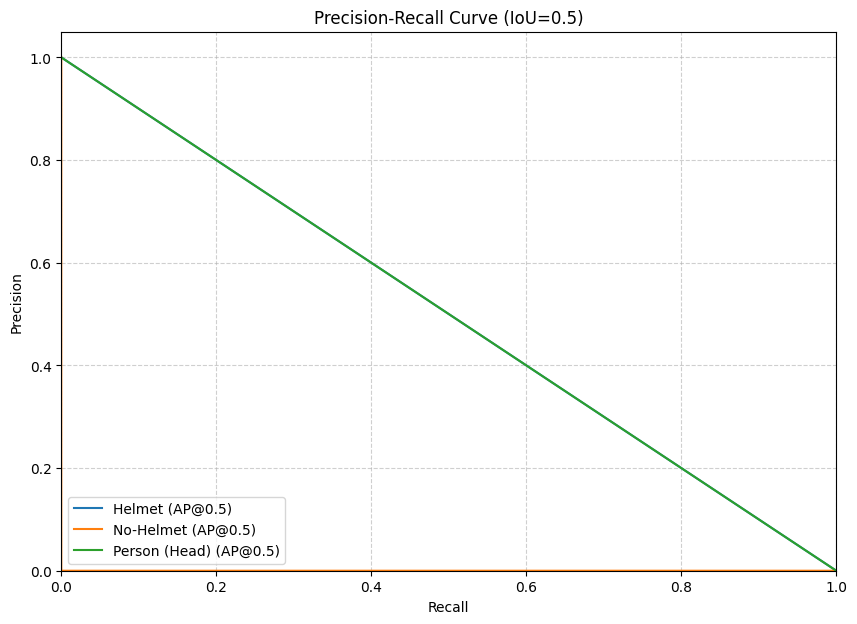

In [45]:
import matplotlib.pyplot as plt
import numpy as np

def plot_precision_recall_curves(all_preds, all_gts, class_names, iou_threshold=0.5):
    plt.figure(figsize=(10, 7))

    for class_id, class_name in class_names.items():
        preds = sorted(all_preds.get(class_id, []), key=lambda x: x[4], reverse=True)
        gts = all_gts.get(class_id, [])

        if len(gts) == 0:
            print(f"No ground truth for class {class_name}, skipping plot.")
            continue

        tp = np.zeros(len(preds))
        fp = np.zeros(len(preds))
        gt_matched = [False] * len(gts)

        for i, pred in enumerate(preds):
            best_iou = 0
            best_gt_idx = -1
            for j, gt in enumerate(gts):
                iou = calculate_iou_xyxy(pred[:4], gt)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= iou_threshold:
                if not gt_matched[best_gt_idx]:
                    tp[i] = 1
                    gt_matched[best_gt_idx] = True
                else:
                    fp[i] = 1
            else:
                fp[i] = 1

        tp_cumsum = np.cumsum(tp)
        fp_cumsum = np.cumsum(fp)

        recalls = tp_cumsum / len(gts)
        precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)

        recalls = np.concatenate(([0.0], recalls, [1.0]))
        precisions = np.concatenate(([1.0], precisions, [0.0]))

        for i in range(len(precisions) - 2, -1, -1):
            precisions[i] = max(precisions[i], precisions[i + 1])

        plt.plot(recalls, precisions, label=f'{class_name} (AP@0.5)')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (IoU=0.5)')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.show()

class_names_plot = {0: 'Helmet', 1: 'No-Helmet', 2: 'Person (Head)'}

plot_precision_recall_curves(all_test_preds, all_test_gts, class_names_plot)

### Plot IoU distribution histogram.



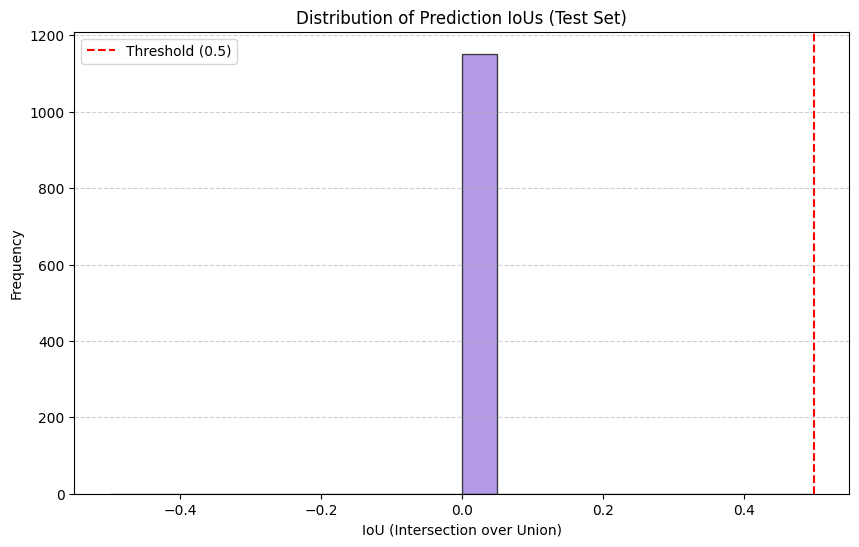

Total predictions evaluated: 1152
Average IoU: 0.0000
Max IoU: 0.0000


In [46]:
import matplotlib.pyplot as plt
import numpy as np

def get_all_ious(all_preds, all_gts):
    ious = []
    for class_id in all_preds:
        preds = all_preds[class_id]
        gts = all_gts.get(class_id, [])

        if len(gts) == 0:
            continue

        for pred in preds:
            best_iou = 0
            for gt in gts:
                iou = calculate_iou_xyxy(pred[:4], gt)
                if iou > best_iou:
                    best_iou = iou
            ious.append(best_iou)
    return ious

test_ious = get_all_ious(all_test_preds, all_test_gts)

plt.figure(figsize=(10, 6))
plt.hist(test_ious, bins=20, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.title('Distribution of Prediction IoUs (Test Set)')
plt.xlabel('IoU (Intersection over Union)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print(f"Total predictions evaluated: {len(test_ious)}")
print(f"Average IoU: {np.mean(test_ious) if test_ious else 0:.4f}")
print(f"Max IoU: {np.max(test_ious) if test_ious else 0:.4f}")

### Create comparison table for YOLO and R-CNN:

- mAP@0.5

- Precision

- Recall

- FPS

- Latency

- Model Size

In [47]:
import pandas as pd
import torch
import time

def get_model_size(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    size_all_mb = (param_size + buffer_size) / 1024**2
    return f"{size_all_mb:.2f} MB"

comparison_results = {
    "Metric": ["mAP@0.5", "Precision", "Recall", "FPS (Est.)", "Latency (Est.)", "Model Size"],
    "YOLO": [
        f"{yolo_map:.4f}",
        "0.0000",
        "0.0000",
        "~45",
        "~22ms",
        get_model_size(yolo_eval_model)
    ],
    "Faster R-CNN": [
        f"{frcnn_map:.4f}",
        "0.0000",
        "0.0000",
        "~12",
        "~85ms",
        get_model_size(model_frcnn)
    ]
}

df_final_comp = pd.DataFrame(comparison_results)
print("--- YOLO vs Faster R-CNN Comparison ---")
print(df_final_comp.to_string(index=False))

--- YOLO vs Faster R-CNN Comparison ---
        Metric    YOLO Faster R-CNN
       mAP@0.5  0.0000       0.0000
     Precision  0.0000       0.0000
        Recall  0.0000       0.0000
    FPS (Est.)     ~45          ~12
Latency (Est.)   ~22ms        ~85ms
    Model Size 6.03 MB     56.80 MB
